# Corrélations et indé vs gros studios

Deuxième moitié de l'analyse exploratoire : on croise les variables entre
elles pour repérer ce qui semble vraiment lié au succès d'un jeu, et on
compare les jeux indépendants aux productions plus importantes. L'objectif
est de sortir de ce notebook avec une liste de variables à utiliser (ou pas)
pour le modèle du Jour 5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/games_clean.csv', parse_dates=['Release date'])

# Un jeu est considéré comme indé si 'Indie' apparaît dans sa liste de genres
# (et pas seulement comme genre principal, contrairement à main_genre).
df['is_indie'] = df['Genres'].fillna('').str.contains('Indie')
print(f"Part de jeux indé dans le catalogue : {df['is_indie'].mean()*100:.1f}%")

Part de jeux indé dans le catalogue : 65.9%


## Matrice de corrélation

On regarde comment les variables numériques se corrèlent entre elles, en
particulier avec nos deux indicateurs de "succès" : `positive_ratio` (qualité
perçue) et `estimated_owners_avg` (popularité).

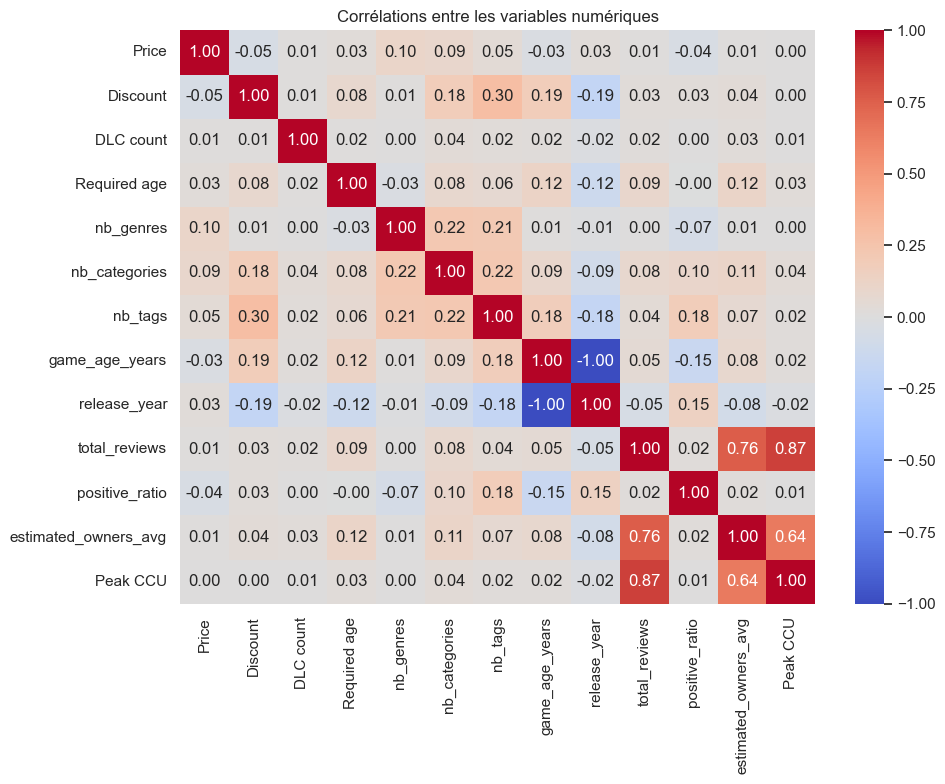

In [2]:
colonnes_numeriques = [
    'Price', 'Discount', 'DLC count', 'Required age', 'nb_genres',
    'nb_categories', 'nb_tags', 'game_age_years', 'release_year',
    'total_reviews', 'positive_ratio', 'estimated_owners_avg', 'Peak CCU'
]

correlations = df[colonnes_numeriques].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Corrélations entre les variables numériques')
plt.tight_layout()
plt.show()

In [3]:
print("Corrélations avec estimated_owners_avg :")
print(correlations['estimated_owners_avg'].sort_values(ascending=False))
print("\nCorrélations avec positive_ratio :")
print(correlations['positive_ratio'].sort_values(ascending=False))

Corrélations avec estimated_owners_avg :
estimated_owners_avg    1.000000
total_reviews           0.760014
Peak CCU                0.641506
Required age            0.116429
nb_categories           0.110246
game_age_years          0.080418
nb_tags                 0.068042
Discount                0.037675
DLC count               0.026782
positive_ratio          0.020206
Price                   0.012389
nb_genres               0.006832
release_year           -0.080418
Name: estimated_owners_avg, dtype: float64

Corrélations avec positive_ratio :
positive_ratio          1.000000
nb_tags                 0.182675
release_year            0.146908
nb_categories           0.100104
Discount                0.029193
estimated_owners_avg    0.020206
total_reviews           0.019406
Peak CCU                0.005334
DLC count               0.003899
Required age           -0.001760
Price                  -0.039444
nb_genres              -0.066645
game_age_years         -0.146908
Name: positive_ratio, 

## Deux constats importants à retenir

**`estimated_owners_avg` est fortement corrélé à `total_reviews` (~0.76) et
à `Peak CCU` (~0.64).** Ce n'est pas vraiment une découverte : Steam ne donne
pas le nombre réel de joueurs, donc cette estimation est elle-même calculée
à partir du nombre d'avis (et d'autres signaux d'activité comme le pic de
joueurs connectés). Utiliser `total_reviews` ou `Peak CCU` comme variable
explicative pour prédire `estimated_owners_avg` reviendrait donc en partie à
prédire une variable à partir d'elle-même (fuite de données). Si tu choisis
`estimated_owners_avg` comme cible au Jour 5, il faudra l'exclure (ou s'en
tenir à des variables vraiment indépendantes : genre, prix, langues, etc.).

**`positive_ratio` n'est, lui, fortement corrélé à rien.** Les corrélations
les plus fortes (`nb_tags`, `release_year`) restent faibles (autour de 0.15-
0.18). Concrètement, la qualité perçue d'un jeu ne s'explique pas bien avec
ces seules métadonnées : c'est plutôt rassurant pour la suite (un modèle
parfait serait suspect), mais ça veut dire qu'il faudra rester modeste sur
les performances attendues si on prédit cette cible.

## Indé vs gros studios

On compare les deux groupes sur le nombre de jeux, le prix moyen, le ratio
d'avis positifs moyen et le nombre de propriétaires estimé moyen.

In [4]:
comparaison = df.groupby('is_indie').agg(
    nb_jeux=('AppID', 'count'),
    prix_moyen=('Price', 'mean'),
    ratio_positif_moyen=('positive_ratio', 'mean'),
    owners_moyen=('estimated_owners_avg', 'mean')
)
comparaison.index = comparaison.index.map({True: 'Indé', False: 'Non-indé'})
comparaison

,nb_jeux,prix_moyen,ratio_positif_moyen,owners_moyen
is_indie,,,,
Non-indé,42970,5.038774,0.741259,135714.801024
Indé,82884,4.693237,0.765029,56504.934607


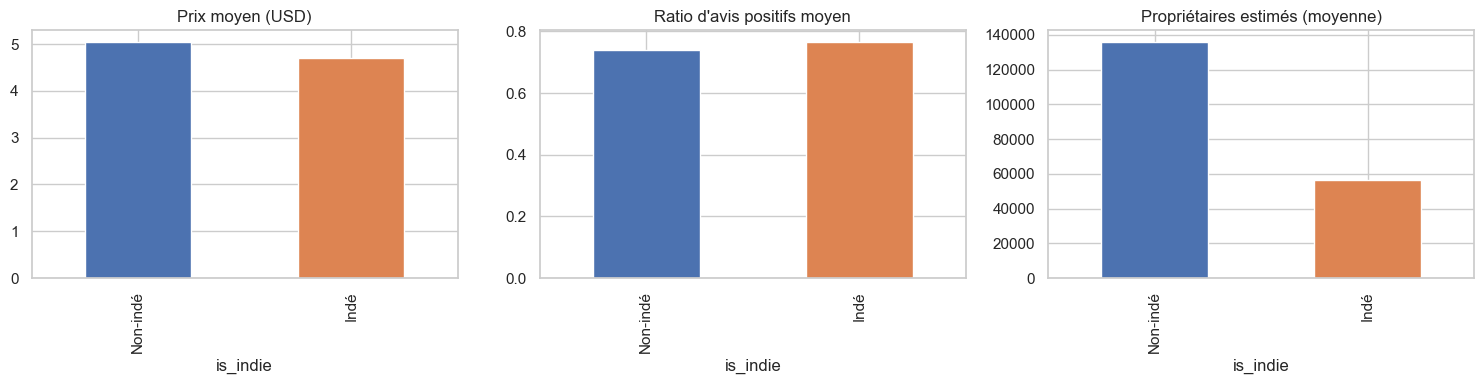

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparaison['prix_moyen'].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Prix moyen (USD)')

comparaison['ratio_positif_moyen'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Ratio d\'avis positifs moyen')

comparaison['owners_moyen'].plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'])
axes[2].set_title('Propriétaires estimés (moyenne)')

plt.tight_layout()
plt.show()

On voit un résultat intéressant pour le storytelling : les jeux indés ont en
moyenne un meilleur ratio d'avis positifs que les non-indés, alors qu'ils
touchent beaucoup moins de joueurs. Autrement dit, être bien noté n'implique
pas d'être largement diffusé, et inversement.

## Évolution de la part d'indé dans les sorties

Au Jour 3 on a vu que le nombre absolu de sorties explose depuis le milieu
des années 2010. Ici on regarde la part que représentent les jeux indés dans
ces sorties chaque année, ce qui raconte une histoire un peu différente.

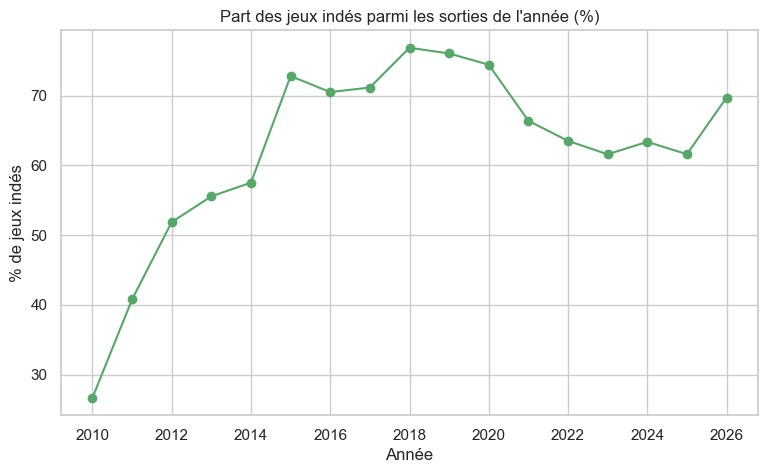

release_year
2017    71.158392
2018    76.866372
2019    76.045837
2020    74.432076
2021    66.386555
2022    63.509115
2023    61.583779
2024    63.375431
2025    61.598526
2026    69.722557
Name: is_indie, dtype: float64


In [6]:
evolution_indie = df[df['release_year'] >= 2010].groupby('release_year')['is_indie'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
evolution_indie.plot(kind='line', marker='o', ax=ax, color='#55A868')
ax.set_title("Part des jeux indés parmi les sorties de l'année (%)")
ax.set_xlabel('Année')
ax.set_ylabel("% de jeux indés")
plt.show()

print(evolution_indie.tail(10))

La part d'indé grimpe jusqu'à un pic autour de 2018, puis redescend et se
stabilise plutôt autour de 60-65% depuis. Le nombre de jeux indés continue
d'augmenter en valeur absolue, mais les productions non-indés
augmentent encore plus vite récemment : la composition du catalogue change,
ce n'est pas juste "de plus en plus d'indé".

## Synthèse

- `estimated_owners_avg` est quasiment redondant avec `total_reviews` et
  `Peak CCU` : à exclure ou à traiter avec précaution comme cible
- `positive_ratio` n'a pas de variable numérique qui l'explique fortement à
  elle seule ; un modèle de classification (par exemple "bien noté" vs "pas
  bien noté" à partir d'un seuil) devra combiner plusieurs variables
  faibles plutôt que de compter sur une seule variable forte
- Le statut indé/non-indé a un effet réel et utilisable : moins de
  propriétaires en moyenne, mais un ratio d'avis positifs légèrement meilleur
- Variables à tester en priorité pour le modèle : `Price`, `main_genre` /
  `is_indie`, `nb_tags`, `nb_categories`, `release_year`, `Required age`,
  `DLC count`